# Sensitivity analysis

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

from matching_metrics import InstrumentedDatingMarket

# SALib: prefer the new sample API, fall back to the template's saltelli import
try:
    from SALib.sample.sobol import sample as sobol_sample
except Exception:
    from SALib.sample import saltelli
    def sobol_sample(problem, N, calc_second_order=True):
        return saltelli.sample(problem, N, calc_second_order=calc_second_order)
from SALib.analyze import sobol as sobol_analyze

# ---- toggle smoke test vs full run ----
QUICK = False


# the 4 parameters under study and their bounds
problem = {
    "num_vars": 4,
    "names":   ["rejection_cost", "rationality", "interaction_radius", "interaction_std"],
    "bounds":  [[0.2, 3.0],       [0.5, 30.0],   [2, 10],              [0.1, 1.0]],
}
INT_PARAMS = {"interaction_radius"}                       # rationality is NOT an integer
BASELINE   = dict(rejection_cost=1.0, rationality=6.0, interaction_radius=5, interaction_std=0.5)

# fixed (non-SA) parameters
THRESH, GBAL, REL_LEN, MEMORY = 0.6, 0.5, 10, 8     


if QUICK:
    N_AGENTS, N_GRID, N_STEPS, BURN_IN = 80, 40, 70, 35
    OFAT_DISTINCT, OFAT_REPS           = 5, 3
    N_SALTELLI, SOBOL_REPS             = 8, 1          # powers of 2 for N are best
else:
    N_AGENTS, N_GRID, N_STEPS, BURN_IN = 120, 45, 140, 60
    OFAT_DISTINCT, OFAT_REPS           = 10, 20
    N_SALTELLI, SOBOL_REPS             = 64, 10

In [2]:
def run_config(rejection_cost, rationality, interaction_radius, interaction_std, seed):
    """One homogeneous-population run; returns steady-state market metrics."""
    m = InstrumentedDatingMarket(n_grid=N_GRID, interaction_std=float(interaction_std),
                                 interaction_radius=int(round(interaction_radius)),
                                 relationship_length=REL_LEN, seed=seed)
    m.add_agents(N_AGENTS, gender_balance=GBAL, move_prob=0.5,
                 rejection_cost=float(rejection_cost), rationality=float(rationality),
                 relation_threshold=THRESH, memory_depth=MEMORY, label="pop")
    nmale = sum(a.is_male for a in m.subjects); npair = nmale * (N_AGENTS - nmale)
    w = b = th = 0.0; k = 0
    for t in range(N_STEPS):
        m.step()
        if t < BURN_IN:
            continue
        k += 1
        om = m.matching_metrics()
        w  += om["welfare_ratio"]
        b  += om["blocking_pairs"] / npair
        th += float(np.mean([m.agent_quality(a) for a in m.subjects]))
    return dict(welfare_ratio=w / k, blocking_frac=b / k, throughput=th / k)


def eval_point(vals, replicates):
    """Mean of each metric over `replicates` seeds for one parameter combination."""
    outs = [run_config(*vals, seed=s) for s in range(replicates)]
    return {key: float(np.mean([o[key] for o in outs])) for key in outs[0]}

## 1. OFAT (one factor at a time)

Vary one parameter across `OFAT_DISTINCT` values while holding the other three at `BASELINE`,
`OFAT_REPS` seeds each. Curves show mean with a 95% confidence band.

In [3]:
ofat = {}                                            # {param: DataFrame}
for i, var in enumerate(problem["names"]):
    samples = np.linspace(*problem["bounds"][i], num=OFAT_DISTINCT)
    if var in INT_PARAMS:
        samples = np.unique(np.round(samples).astype(int))
    rows = []
    for val in samples:
        for s in range(OFAT_REPS):
            args = dict(BASELINE); args[var] = val
            out = run_config(**args, seed=s)
            rows.append({var: val, **out})
    ofat[var] = pd.DataFrame(rows)
    print(f"OFAT done: {var} ({len(samples)} values x {OFAT_REPS} reps)")

OFAT done: rejection_cost (10 values x 20 reps)
OFAT done: rationality (10 values x 20 reps)
OFAT done: interaction_radius (9 values x 20 reps)
OFAT done: interaction_std (10 values x 20 reps)


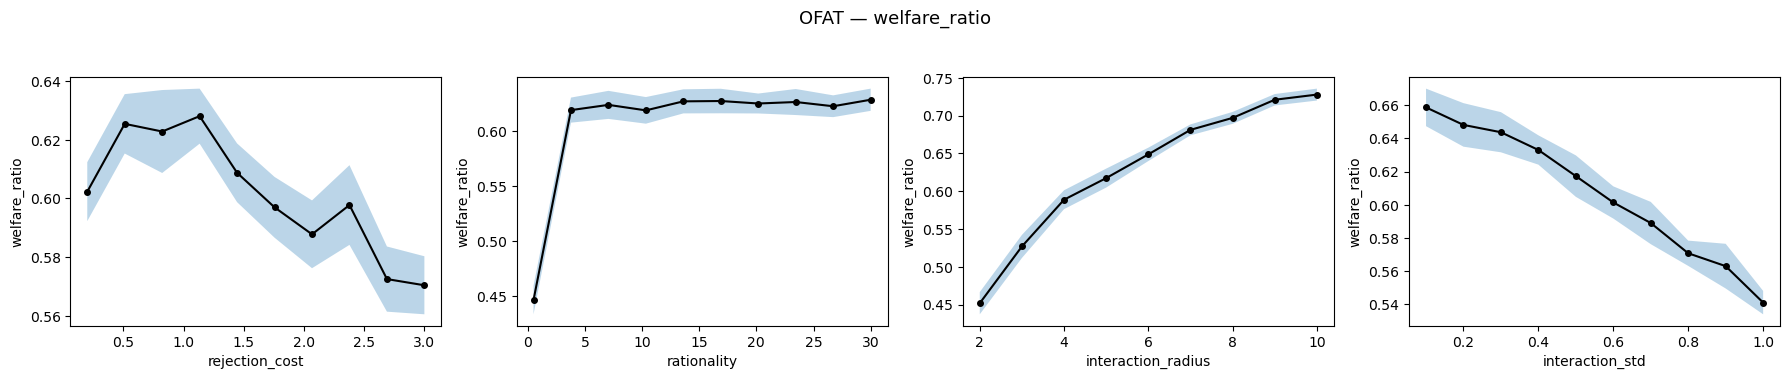

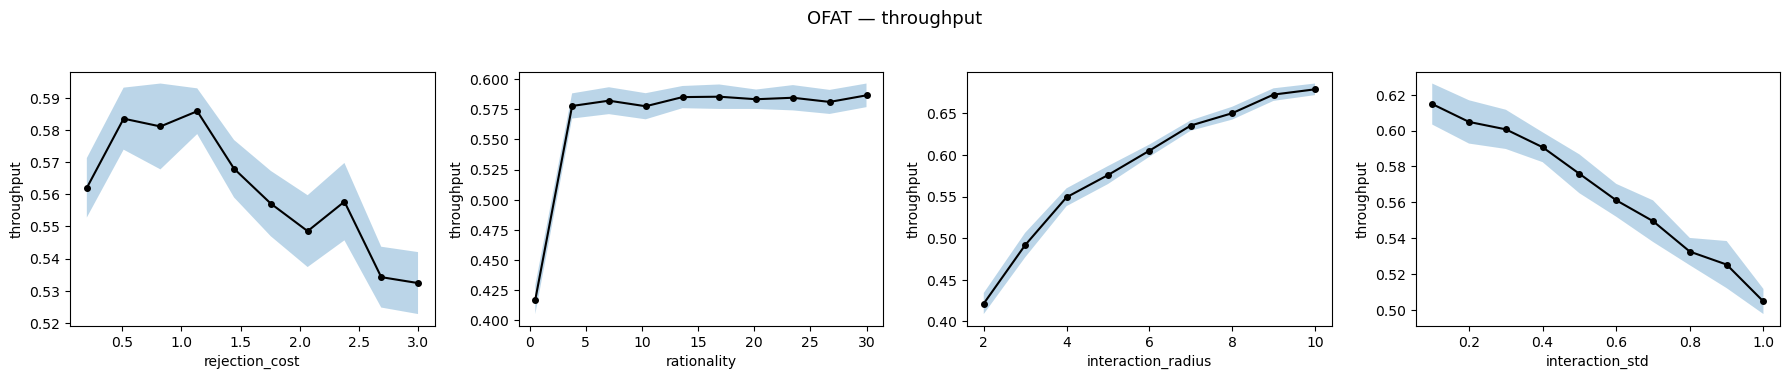

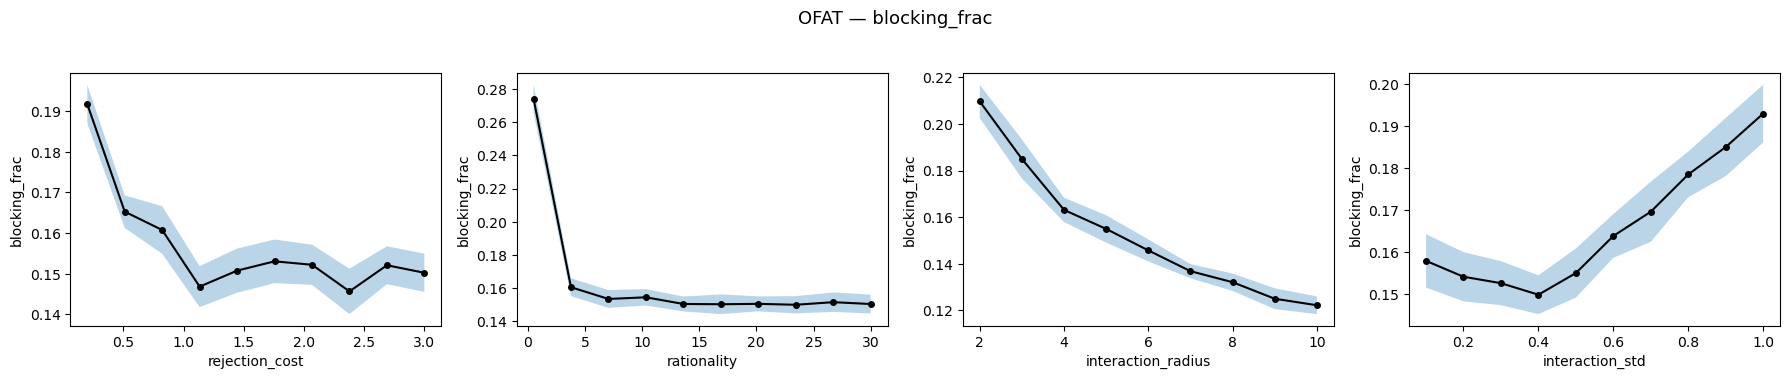

In [4]:
def plot_ofat(metric):
    fig, axs = plt.subplots(1, 4, figsize=(18, 3.6))
    for ax, var in zip(axs, problem["names"]):
        df = ofat[var]
        g = df.groupby(var)[metric]
        x = g.mean().index.values; y = g.mean().values
        err = 1.96 * g.std().values / np.sqrt(g.count().values)
        ax.plot(x, y, "-o", c="k", ms=4)
        ax.fill_between(x, y - err, y + err, alpha=.3)
        ax.set_xlabel(var); ax.set_ylabel(metric)
    fig.suptitle(f"OFAT — {metric}", y=1.04, fontsize=13)
    plt.tight_layout(); plt.show()

for metric in ("welfare_ratio", "throughput", "blocking_frac"):
    plot_ofat(metric)

## 2. Sobol (global variance decomposition)

Saltelli sampling gives `N x (2D+2)` parameter combinations (D=4, second-order on → 10 per base
sample). Each combination is run `SOBOL_REPS` times and **averaged** to one Y value, then
`sobol.analyze` attributes the output variance to each parameter (S1 = first order / main effect),
to all interactions involving it (ST = total order), and to each pair (S2).

A converged result has `0 <= S1 <= ST <= 1` and small confidence intervals. **Negative indices
or ST > 1 mean N is too small** — raise `N_SALTELLI` (next power of 2) and/or `SOBOL_REPS`.

In [5]:
X = sobol_sample(problem, N_SALTELLI, calc_second_order=True)
print(f"{X.shape[0]} parameter combinations (= N*(2D+2) = {N_SALTELLI}*10),"
      f" x {SOBOL_REPS} replicates = {X.shape[0]*SOBOL_REPS} runs")

records = []
for c, row in enumerate(X):
    out = eval_point(row, SOBOL_REPS)
    records.append({**{n: row[i] for i, n in enumerate(problem["names"])}, **out})
    if (c + 1) % max(1, X.shape[0] // 10) == 0:
        print(f"  {100*(c+1)/X.shape[0]:.0f}% ({c+1}/{X.shape[0]})")

sobol_df = pd.DataFrame(records)
sobol_df.to_csv("sobol_results.csv", index=False)     # save so you can re-analyse without re-running
sobol_df.head()

640 parameter combinations (= N*(2D+2) = 64*10), x 10 replicates = 6400 runs
  10% (64/640)
  20% (128/640)
  30% (192/640)
  40% (256/640)
  50% (320/640)
  60% (384/640)
  70% (448/640)
  80% (512/640)
  90% (576/640)
  100% (640/640)


,rejection_cost,rationality,interaction_radius,interaction_std,welfare_ratio,blocking_frac,throughput
0,2.915584,18.248288,6.171282,0.989872,0.498953,0.186114,0.465229
1,2.819442,18.248288,6.171282,0.989872,0.488778,0.193026,0.455754
2,2.915584,8.112177,6.171282,0.989872,0.495192,0.187537,0.461795
3,2.915584,18.248288,4.486588,0.989872,0.393712,0.223548,0.367088
4,2.915584,18.248288,6.171282,0.992149,0.491335,0.190352,0.458154


In [6]:
Si = {}
for metric in ("welfare_ratio", "blocking_frac"):
    Si[metric] = sobol_analyze.analyze(problem, sobol_df[metric].values,
                                       calc_second_order=True, print_to_console=False)
    print(f"=== {metric} ===")
    for nm, s1, st in zip(problem["names"], Si[metric]["S1"], Si[metric]["ST"]):
        print(f"  {nm:>20}  S1={s1:6.3f}  ST={st:6.3f}")
    print()

=== welfare_ratio ===
        rejection_cost  S1= 0.021  ST= 0.072
           rationality  S1= 0.043  ST= 0.043
    interaction_radius  S1= 0.668  ST= 0.641
       interaction_std  S1= 0.205  ST= 0.207

=== blocking_frac ===
        rejection_cost  S1= 0.043  ST= 0.098
           rationality  S1= 0.202  ST= 0.161
    interaction_radius  S1= 0.544  ST= 0.493
       interaction_std  S1= 0.257  ST= 0.215



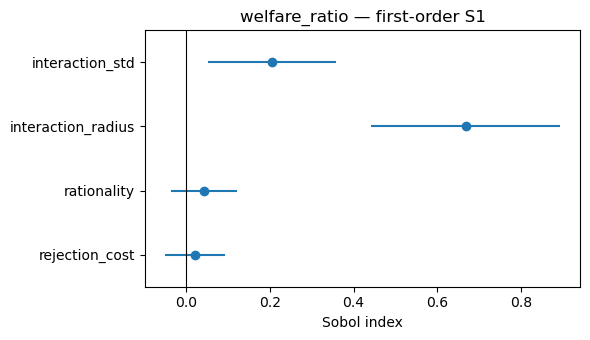

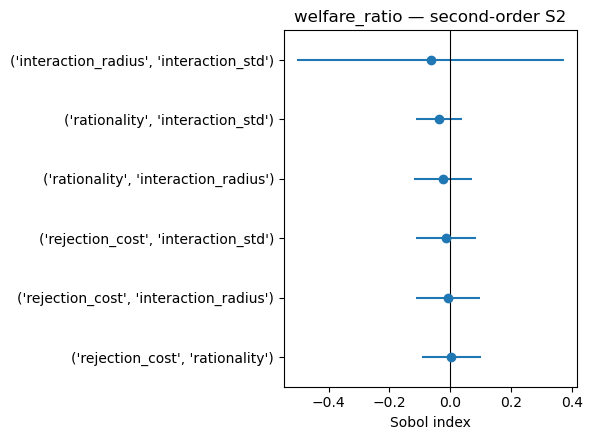

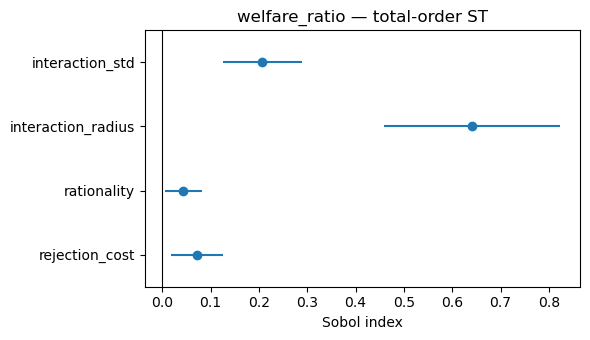

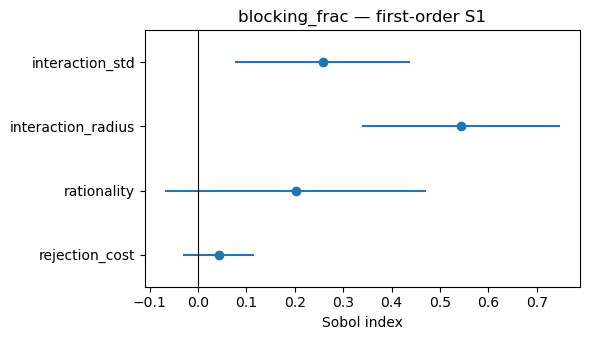

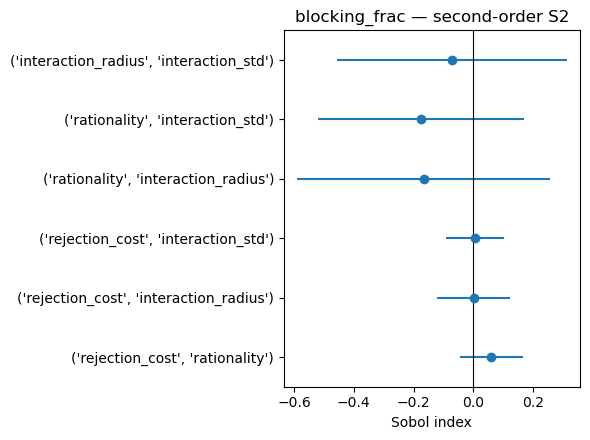

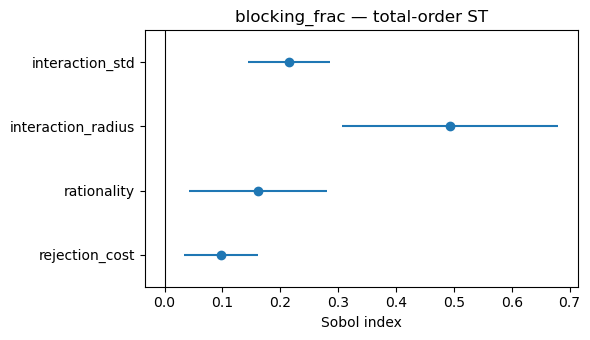

In [7]:
def plot_index(s, params, order, title=""):
    """Course-template style index plot. order in {'1','2','T'}."""
    if order == "2":
        p = len(params)
        names = list(combinations(params, 2))
        idx = s["S2"].reshape(p ** 2); idx = idx[~np.isnan(idx)]
        err = s["S2_conf"].reshape(p ** 2); err = err[~np.isnan(err)]
    else:
        names = params; idx = s["S" + order]; err = s["S" + order + "_conf"]
    l = len(idx)
    plt.figure(figsize=(6, 0.5 * l + 1.5))
    plt.title(title); plt.ylim([-0.5, l - 0.5])
    plt.yticks(range(l), names)
    plt.errorbar(idx, range(l), xerr=err, linestyle="None", marker="o")
    plt.axvline(0, c="k", lw=.8); plt.xlabel("Sobol index")
    plt.tight_layout(); plt.show()

for metric in ("welfare_ratio", "blocking_frac"):
    plot_index(Si[metric], problem["names"], "1", f"{metric} — first-order S1")
    plot_index(Si[metric], problem["names"], "2", f"{metric} — second-order S2")
    plot_index(Si[metric], problem["names"], "T", f"{metric} — total-order ST")

## 3. How much does each parameter account for?

Three views of the same decomposition:
- **Pie** — share of variance from each parameter's *main effect* (clipped S1), with the
  leftover lumped as **interactions** (= 1 − ΣS1). The direct "how much each accounts for".
- **S1 vs ST bars** — main effect vs total effect; a big gap (ST ≫ S1) means that parameter
  acts mostly *through interactions* with others.
- **S2 heatmap** — which specific pairs interact (watch `interaction_radius x interaction_std`).

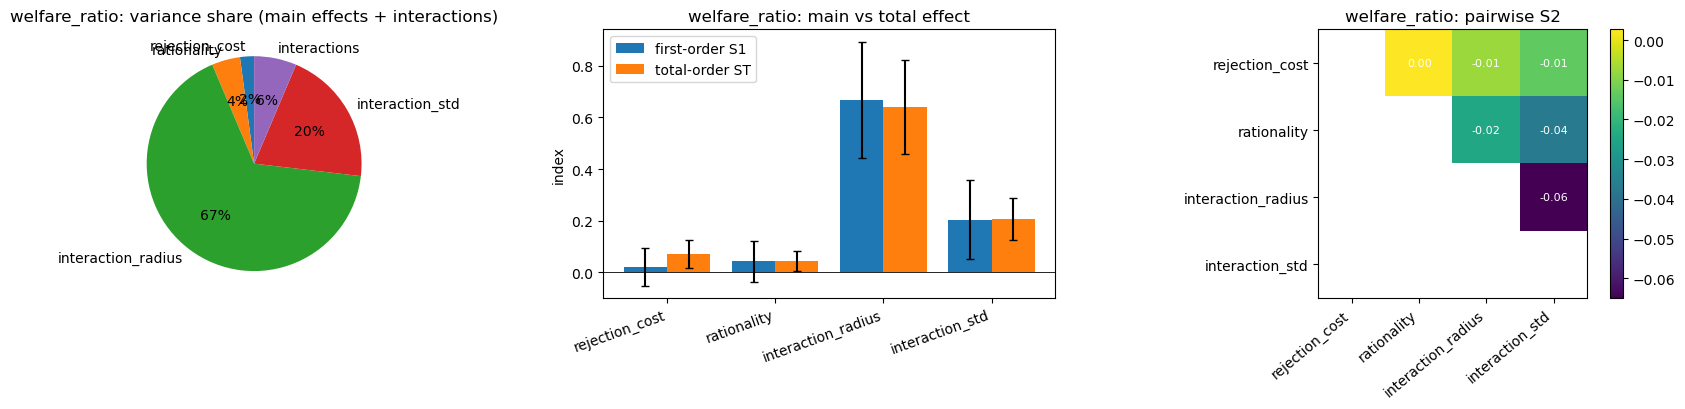

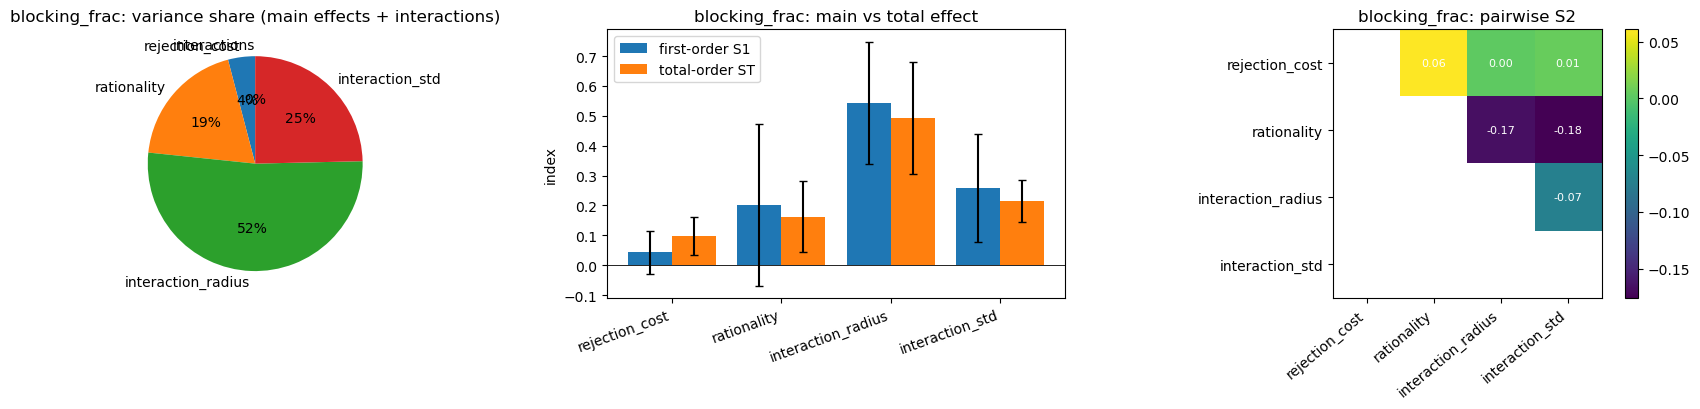

In [8]:
def variance_views(metric):
    s = Si[metric]; names = problem["names"]; D = len(names)
    s1 = np.clip(np.array(s["S1"]), 0, None)
    inter = max(0.0, 1 - s1.sum())

    fig = plt.figure(figsize=(17, 4.2))
    # --- pie: variance share ---
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.pie(list(s1) + [inter], labels=names + ["interactions"],
            autopct="%1.0f%%", startangle=90,
            colors=plt.cm.tab10(np.arange(D + 1)))
    ax1.set_title(f"{metric}: variance share (main effects + interactions)")

    # --- S1 vs ST grouped bars ---
    ax2 = fig.add_subplot(1, 3, 2)
    x = np.arange(D)
    ax2.bar(x - 0.2, s["S1"], 0.4, yerr=s["S1_conf"], capsize=3, label="first-order S1")
    ax2.bar(x + 0.2, s["ST"], 0.4, yerr=s["ST_conf"], capsize=3, label="total-order ST")
    ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, ha="right")
    ax2.axhline(0, c="k", lw=.6); ax2.set_ylabel("index"); ax2.legend()
    ax2.set_title(f"{metric}: main vs total effect")

    # --- S2 heatmap ---
    ax3 = fig.add_subplot(1, 3, 3)
    S2 = np.array(s["S2"]); M = np.full((D, D), np.nan)
    for i in range(D):
        for j in range(i + 1, D):
            M[i, j] = S2[i, j]
    im = ax3.imshow(M, cmap="viridis")
    ax3.set_xticks(range(D)); ax3.set_xticklabels(names, rotation=40, ha="right")
    ax3.set_yticks(range(D)); ax3.set_yticklabels(names)
    for i in range(D):
        for j in range(i + 1, D):
            ax3.text(j, i, f"{S2[i,j]:.2f}", ha="center", va="center",
                     color="w", fontsize=8)
    fig.colorbar(im, ax=ax3, fraction=0.046); ax3.set_title(f"{metric}: pairwise S2")
    plt.tight_layout(); plt.show()

for metric in ("welfare_ratio", "blocking_frac"):
    variance_views(metric)